
<img src="C:\Users\swath\Downloads\omato-logo-vector-png_1020x.jpg" width="100%">


### The dataset contains information about restaurants listed on Zomato in Bangalore, including details like restaurant name, address, location, and contact number.It also includes service features such as online ordering, table booking availability, ratings, and number of votes given by users.
### Additionally, the dataset provides information about restaurant type, cuisines, approximate cost for two people, customer reviews, and listing categories to analyze restaurant popularity and performance.

In [1]:
#load the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split

In [2]:
# load the dataset
df=pd.read_csv(r"C:\Users\swath\Downloads\archive (37)\zomato.csv",encoding="ISO-8859-1")

In [3]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [4]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [5]:
df.shape

(51717, 17)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [7]:
df.describe(include="object")

,url,address,name,online_order,book_table,rate,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
count,51717,51717,51717,51717,51717,43942,50509,51696,51490,23639,51672,51371,51717,51717,51717,51717
unique,51717,11495,8792,2,2,64,14926,93,93,5271,2723,70,22513,9098,7,30
top,https://www.zomato.com/bangalore/jalsa-banasha...,Delivery Only,Cafe Coffee Day,Yes,No,NEW,080 43334321,BTM,Quick Bites,Biryani,North Indian,300,[],[],Delivery,BTM
freq,1,128,96,30444,45268,2208,216,5124,19132,182,2913,7576,7595,39617,25942,3279


In [8]:
df.describe(include="number")

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [9]:
#droping unwanted columns
df.drop(['url', 'address','online_order', 'book_table','phone','rest_type','dish_liked','reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],axis=1,inplace=True)

In [10]:
df.head()

,name,rate,votes,location,cuisines,approx_cost(for two people)
0,Jalsa,4.1/5,775,Banashankari,"North Indian, Mughlai, Chinese",800
1,Spice Elephant,4.1/5,787,Banashankari,"Chinese, North Indian, Thai",800
2,San Churro Cafe,3.8/5,918,Banashankari,"Cafe, Mexican, Italian",800
3,Addhuri Udupi Bhojana,3.7/5,88,Banashankari,"South Indian, North Indian",300
4,Grand Village,3.8/5,166,Basavanagudi,"North Indian, Rajasthani",600


In [11]:
df.dtypes

name                           object
rate                           object
votes                           int64
location                       object
cuisines                       object
approx_cost(for two people)    object
dtype: object

# FEATURE ENGINEERING

In [12]:
df['rate'] = df['rate'].str.replace('/5', '')
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')


In [13]:
df = df.rename(columns={"rate": "Rating(/5)"})

In [14]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         51717 non-null  object 
 1   Rating(/5)                   41665 non-null  float64
 2   votes                        51717 non-null  int64  
 3   location                     51696 non-null  object 
 4   cuisines                     51672 non-null  object 
 5   approx_cost(for two people)  51371 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 2.4+ MB


# HANDLING MISSING VALUES

In [16]:
df.isnull().sum()

name                               0
Rating(/5)                     10052
votes                              0
location                          21
cuisines                          45
approx_cost(for two people)      346
dtype: int64

<Axes: >

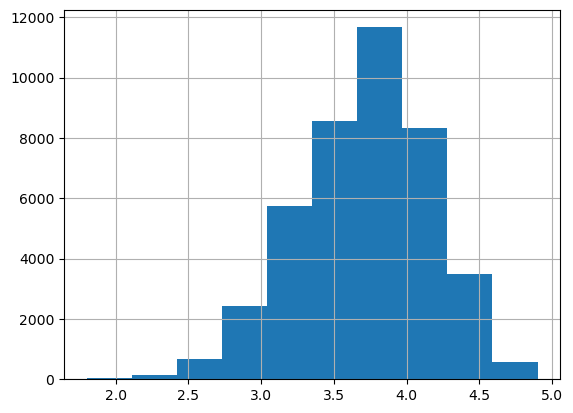

In [17]:
df["Rating(/5)"].hist()

<Axes: >

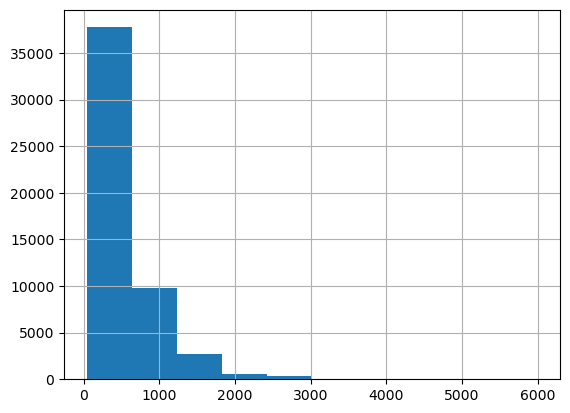

In [18]:
df["approx_cost(for two people)"].hist()

In [19]:
for i in ["approx_cost(for two people)","Rating(/5)"]:
    df[i]=df[i].fillna(df[i].median())

In [20]:
for i in ["cuisines","location"]:
    df[i]=df[i].fillna(df[i].mode()[0])

In [21]:
df.isnull().sum()

name                           0
Rating(/5)                     0
votes                          0
location                       0
cuisines                       0
approx_cost(for two people)    0
dtype: int64

# CHECKING DUPLICATES

In [22]:
df.duplicated().sum()

31388

In [23]:
df = df.drop_duplicates()

In [24]:
df.duplicated().sum()

0

In [25]:
df.head()

,name,Rating(/5),votes,location,cuisines,approx_cost(for two people)
0,Jalsa,4.1,775,Banashankari,"North Indian, Mughlai, Chinese",800.0
1,Spice Elephant,4.1,787,Banashankari,"Chinese, North Indian, Thai",800.0
2,San Churro Cafe,3.8,918,Banashankari,"Cafe, Mexican, Italian",800.0
3,Addhuri Udupi Bhojana,3.7,88,Banashankari,"South Indian, North Indian",300.0
4,Grand Village,3.8,166,Basavanagudi,"North Indian, Rajasthani",600.0


## HANDLING OUTLIERS

<Axes: >

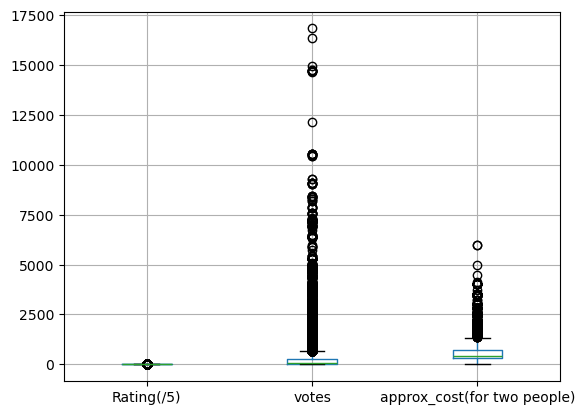

In [26]:
df.boxplot()

In [27]:
for i in ["votes","approx_cost(for two people)","Rating(/5)"]:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1
    upper_limit=q3+1.5*iqr
    lower_limit=q1-1.5*iqr
    df[i]=df[i].clip(upper_limit,lower_limit)

<Axes: >

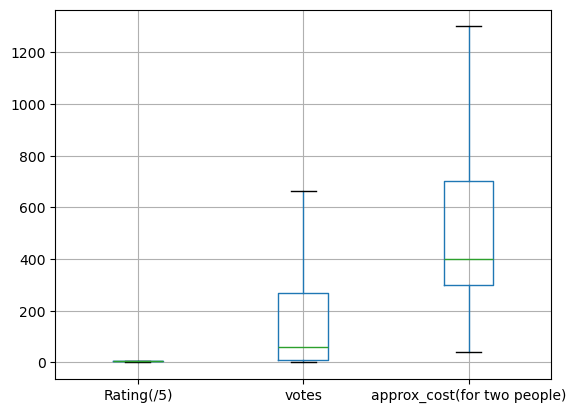

In [28]:
df.boxplot()

In [26]:
# checking each columns unique values
for i in df:
    print(i)
    print("*"*20)
    print(df[i].unique())
    print("*"*20)
    print(df[i].nunique())
    print("\n")

name
********************
['Jalsa' 'Spice Elephant' 'San Churro Cafe' ... 'Nawabs Empire'
 'SeeYa Restaurant'
 'Plunge - Sheraton Grand Bengaluru Whitefield Hotel &...']
********************
8792


Rating(/5)
********************
[4.1 3.8 3.7 3.6 4.6 4.  4.2 3.9 3.1 3.  3.2 3.3 2.8 4.4 4.3 2.9 3.5 2.6
 3.4 4.5 2.5 2.7 4.7 2.4 2.2 2.3 4.8 4.9 2.1 2.  1.8]
********************
31


votes
********************
[ 775  787  918 ... 4957 2382  843]
********************
2328


location
********************
['Banashankari' 'Basavanagudi' 'Mysore Road' 'Jayanagar'
 'Kumaraswamy Layout' 'Rajarajeshwari Nagar' 'Vijay Nagar' 'Uttarahalli'
 'JP Nagar' 'South Bangalore' 'City Market' 'Nagarbhavi'
 'Bannerghatta Road' 'BTM' 'Kanakapura Road' 'Bommanahalli'
 'CV Raman Nagar' 'Electronic City' 'HSR' 'Marathahalli' 'Sarjapur Road'
 'Wilson Garden' 'Shanti Nagar' 'Koramangala 5th Block'
 'Koramangala 8th Block' 'Richmond Road' 'Koramangala 7th Block'
 'Jalahalli' 'Koramangala 4th Block' 'Bellandur' 'White

### Top restaurants based on rating

In [27]:
top_restaurants = df.sort_values(by="Rating(/5)", ascending=False)
top_restaurants[["name", "Rating(/5)"]].head(10)

,name,Rating(/5)
37843,Belgian Waffle Factory,4.9
42381,Belgian Waffle Factory,4.9
11504,Asia Kitchen By Mainland China,4.9
6746,Flechazo,4.9
18496,Milano Ice Cream,4.9
3921,Byg Brewski Brewing Company,4.9
8260,AB's - Absolute Barbecues,4.9
26497,Asia Kitchen By Mainland China,4.9
11745,Belgian Waffle Factory,4.9
36684,Asia Kitchen By Mainland China,4.9


### Most common cuisines

In [30]:
cuisine_counts = (df["cuisines"].str.split(", ").explode().value_counts().sort_values(ascending=False))
print(cuisine_counts.head(10))

cuisines
North Indian    8370
Chinese         5981
South Indian    3418
Fast Food       3160
Biryani         2778
Continental     2211
Desserts        2112
Beverages       1956
Cafe            1655
Italian         1299
Name: count, dtype: int64


<Axes: xlabel='cuisines'>

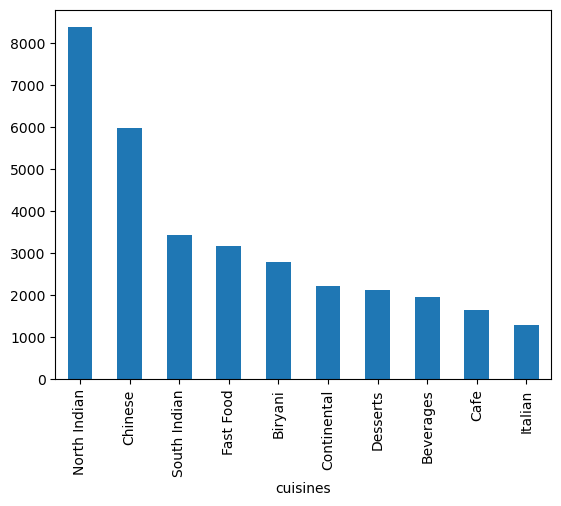

In [31]:
cuisine_counts.head(10).plot(kind="bar")

## Location with highest average rating

In [33]:
avg_rating_location = (df.groupby("location")["Rating(/5)"].mean().sort_values(ascending=False))
print(avg_rating_location.head())

location
Lavelle Road             4.186735
Koramangala 5th Block    4.111896
St. Marks Road           4.109167
Church Street            4.047826
Koramangala 3rd Block    4.039655
Name: Rating(/5), dtype: float64


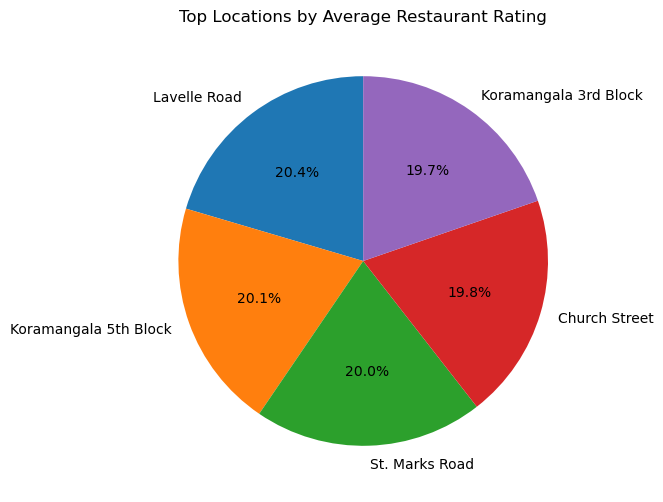

In [34]:
top_locations = avg_rating_location.head(5)

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    top_locations,
    labels=top_locations.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Top Locations by Average Restaurant Rating")
plt.show()

### Rating Distribution

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


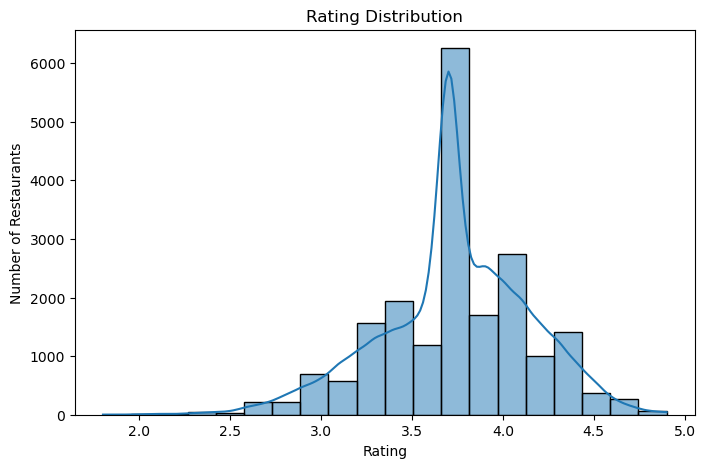

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df["Rating(/5)"], bins=20, kde=True)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.show()

### Votes vs Rating Relationship

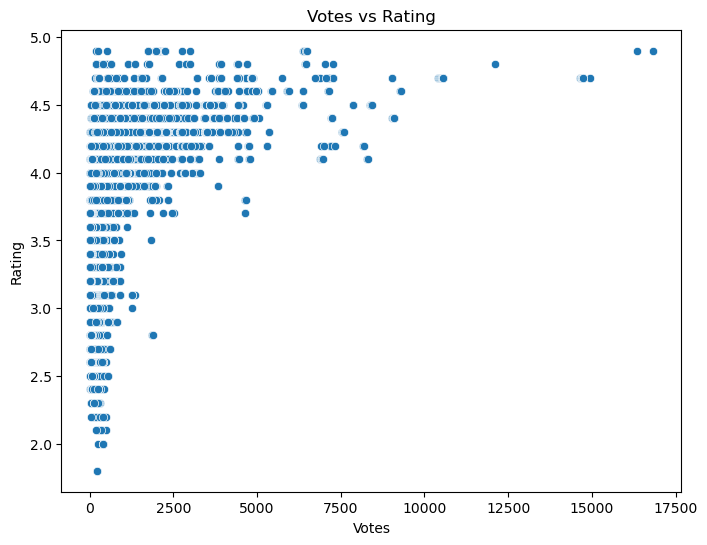

In [36]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["votes"], y=df["Rating(/5)"])
plt.title("Votes vs Rating")
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.show()

### Top 5 Most Expensive Restaurants

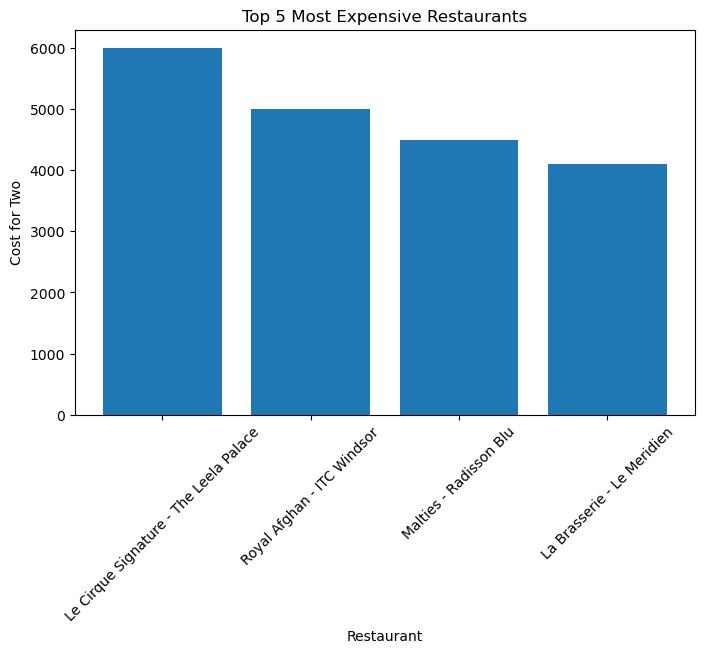

In [40]:
top_expensive = df.sort_values(by="approx_cost(for two people)", ascending=False).head(5)
plt.figure(figsize=(8,5))
plt.bar(top_expensive["name"], top_expensive["approx_cost(for two people)"])
plt.title("Top 5 Most Expensive Restaurants")
plt.xlabel("Restaurant")
plt.ylabel("Cost for Two")
plt.xticks(rotation=45)
plt.show()

# ENCODING

In [27]:
df.drop("name", axis=1,inplace=True)

In [28]:
le = LabelEncoder()
df["location"] = le.fit_transform(df["location"])

In [29]:
df['cuisines'] = df['cuisines'].str.split(',')

In [30]:
mlb = MultiLabelBinarizer()
cuisine_encoded = pd.DataFrame(
    mlb.fit_transform(df['cuisines']),
    columns=mlb.classes_,
    index=df.index
)
df = df.join(cuisine_encoded)
df = df.drop('cuisines', axis=1)

In [31]:
df.head()

,Rating(/5),votes,location,approx_cost(for two people),Afghan,Afghani,African,American,Andhra,Arabian,...,Spanish,Steak,Street Food,Sushi,Tamil,Tea,Thai,Tibetan,Turkish,Vietnamese
0,4.1,775,1,800.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4.1,787,1,800.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3.8,918,1,800.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3.7,88,1,300.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3.8,166,4,600.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
df.columns

Index(['Rating(/5)', 'votes', 'location', 'approx_cost(for two people)',
       ' Afghan', ' Afghani', ' African', ' American', ' Andhra', ' Arabian',
       ...
       'Spanish', 'Steak', 'Street Food', 'Sushi', 'Tamil', 'Tea', 'Thai',
       'Tibetan', 'Turkish', 'Vietnamese'],
      dtype='object', length=194)

In [33]:
data=df.copy()

In [34]:
data=data.drop("Rating(/5)",axis=1)

# SCALING

In [35]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
for i in data:
    df[i]=sc.fit_transform(df[[i]])

In [36]:
df

,Rating(/5),votes,location,approx_cost(for two people),Afghan,Afghani,African,American,Andhra,Arabian,...,Spanish,Steak,Street Food,Sushi,Tamil,Tea,Thai,Tibetan,Turkish,Vietnamese
0,4.1,0.459173,-1.329185,0.490355,-0.038444,-0.012149,-0.012149,-0.140221,-0.115364,-0.098921,...,-0.019841,-0.032915,-0.135779,-0.012149,-0.015685,-0.058359,-0.054408,-0.057504,-0.03509,-0.028066
1,4.1,0.472301,-1.329185,0.490355,-0.038444,-0.012149,-0.012149,-0.140221,-0.115364,-0.098921,...,-0.019841,-0.032915,-0.135779,-0.012149,-0.015685,-0.058359,-0.054408,-0.057504,-0.03509,-0.028066
2,3.8,0.615613,-1.329185,0.490355,-0.038444,-0.012149,-0.012149,-0.140221,-0.115364,-0.098921,...,-0.019841,-0.032915,-0.135779,-0.012149,-0.015685,-0.058359,-0.054408,-0.057504,-0.03509,-0.028066
3,3.7,-0.292397,-1.329185,-0.585194,-0.038444,-0.012149,-0.012149,-0.140221,-0.115364,-0.098921,...,-0.019841,-0.032915,-0.135779,-0.012149,-0.015685,-0.058359,-0.054408,-0.057504,-0.03509,-0.028066
4,3.8,-0.207066,-1.219597,0.060136,-0.038444,-0.012149,-0.012149,-0.140221,-0.115364,-0.098921,...,-0.019841,-0.032915,-0.135779,-0.012149,-0.015685,-0.058359,-0.054408,-0.057504,-0.03509,-0.028066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51627,3.7,-0.388668,-0.415958,-0.585194,-0.038444,-0.012149,-0.012149,-0.140221,-0.115364,-0.098921,...,-0.019841,-0.032915,-0.135779,-0.012149,-0.015685,-0.058359,-0.054408,-0.057504,-0.03509,-0.028066
51628,4.2,0.060961,-1.146539,2.641454,-0.038444,-0.012149,-0.012149,-0.140221,-0.115364,-0.098921,...,-0.019841,-0.032915,-0.135779,-0.012149,-0.015685,-0.058359,-0.054408,-0.057504,-0.03509,-0.028066
51632,3.3,-0.384292,-0.123725,-0.477639,-0.038444,-0.012149,-0.012149,-0.140221,-0.115364,-0.098921,...,-0.019841,-0.032915,-0.135779,-0.012149,-0.015685,-0.058359,-0.054408,-0.057504,-0.03509,-0.028066
51677,2.5,-0.300055,1.885374,0.490355,-0.038444,-0.012149,-0.012149,-0.140221,-0.115364,-0.098921,...,-0.019841,-0.032915,-0.135779,-0.012149,-0.015685,-0.058359,-0.054408,-0.057504,-0.03509,-0.028066


# Feature selection

In [37]:
x=df.drop('Rating(/5)',axis=1)

In [38]:
y=df['Rating(/5)']

# Train-Test Split

In [39]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=42)

#  CLASSICAL ML Model training 

### LINEAR REGRESSION

In [40]:
from sklearn.linear_model import LinearRegression

In [41]:
linear=LinearRegression()

In [42]:
linear.fit(x_train,y_train)

LinearRegression()

In [43]:
y_linear=linear.predict(x_test)

In [44]:
from sklearn.metrics import r2_score,mean_squared_error

In [45]:
r2_linear=r2_score(y_test,y_linear)
r2_linear

0.32635520204582535

In [46]:
mse_linear=mean_squared_error(y_test,y_linear)
mse_linear

0.11500665195683941

### RANDOM FOREST REGRESSOR

In [47]:
from sklearn.ensemble import RandomForestRegressor

In [48]:
rf=RandomForestRegressor()

In [49]:
rf.fit(x_train,y_train)

RandomForestRegressor()

In [50]:
y_rf=rf.predict(x_test)

In [51]:
#model evaluation
r2_rf=r2_score(y_test,y_rf)
r2_rf

0.7073276391742651

In [52]:
#model evaluation
mse_rf=mean_squared_error(y_test,y_rf)
mse_rf

0.04996589959737435

### DECISION TREE REGRESSOR

In [53]:
from sklearn.tree import DecisionTreeRegressor

In [54]:
dt=DecisionTreeRegressor()

In [55]:
dt.fit(x_train,y_train)

DecisionTreeRegressor()

In [56]:
y_dt=dt.predict(x_test)

In [57]:
#model evaluation
r2_dt=r2_score(y_test,y_dt)
r2_dt

0.5389050550996163

In [58]:
#model evaluation
mse_dt=mean_squared_error(y_test,y_dt)
mse_dt

0.07871950619712768

# Deep Learning Model

In [59]:
#importing libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [60]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

In [61]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [62]:
history = model.fit(x_train,y_train,epochs=30,batch_size=32,validation_split=0.2)

Epoch 1/30


382/382 [==============================] - 3s 4ms/step - loss: 1.0519 - mae: 0.6070 - val_loss: 0.2811 - val_mae: 0.3287
Epoch 2/30
382/382 [==============================] - 1s 3ms/step - loss: 0.1832 - mae: 0.2990 - val_loss: 0.1653 - val_mae: 0.2922
Epoch 3/30
382/382 [==============================] - 1s 3ms/step - loss: 0.1316 - mae: 0.2672 - val_loss: 0.1526 - val_mae: 0.2813
Epoch 4/30
382/382 [==============================] - 1s 3ms/step - loss: 0.1213 - mae: 0.2566 - val_loss: 0.1348 - val_mae: 0.2713
Epoch 5/30
382/382 [==============================] - 1s 3ms/step - loss: 0.1120 - mae: 0.2493 - val_loss: 0.1358 - val_mae: 0.2759
Epoch 6/30
382/382 [==============================] - 1s 3ms/step - loss: 0.1114 - mae: 0.2456 - val_loss: 0.1421 - val_mae: 0.2712
Epoch 7/30
382/382 [==============================] - 1s 3ms/step - loss: 0.1094 - mae: 0.2437 - val_loss: 0.1315 - val_mae: 0.2627
Epoch 8/30
382/382 [==============================] - 1s 3ms/step - loss: 

In [63]:
#model evaluation
loss, mae = model.evaluate(x_test, y_test)
print("Test MAE:",mae)

159/159 [==============================] - 0s 2ms/step - loss: 0.1292 - mae: 0.2553
Test MAE: 0.25531482696533203


# PREDICTION

## ML PREDICTION

In [64]:
from tabulate import tabulate
table=[["MODEL","R2 SCORE"],["LINEAR REGRESSION",r2_linear],["RANDOM FOREST",r2_rf],["DECISION TREE",r2_dt]]
print(tabulate(table,headers="firstrow",tablefmt="fancygrid"))

MODEL                R2 SCORE
-----------------  ----------
LINEAR REGRESSION    0.326355
RANDOM FOREST        0.707328
DECISION TREE        0.538905


In [65]:
x_test.head(2)

,votes,location,approx_cost(for two people),Afghan,Afghani,African,American,Andhra,Arabian,Asian,...,Spanish,Steak,Street Food,Sushi,Tamil,Tea,Thai,Tibetan,Turkish,Vietnamese
18501,0.619989,-0.379429,-0.907859,-0.038444,-0.012149,-0.012149,-0.140221,-0.115364,-0.098921,-0.13949,...,-0.019841,-0.032915,-0.135779,-0.012149,-0.015685,-0.058359,-0.054408,-0.057504,-0.03509,-0.028066
49238,-0.281457,-1.146539,-0.154974,-0.038444,-0.012149,-0.012149,-0.140221,-0.115364,10.109050,-0.13949,...,-0.019841,-0.032915,-0.135779,-0.012149,-0.015685,-0.058359,-0.054408,-0.057504,-0.03509,-0.028066


In [66]:
y_test.head(2)

18501    4.6
49238    2.8
Name: Rating(/5), dtype: float64

In [67]:
new_data = x_test.iloc[[0]]

In [68]:
ml_prediction=rf.predict(new_data)
ml_prediction

array([4.6])

## DL PREDICTION

In [70]:
predictions = model.predict(x_test)
print(predictions[:1])

159/159 [==============================] - 1s 3ms/step
[[4.3705974]]


| Model                            | Predicted Rating | Difference from Actual |
| -------------------------------- | ---------------- | ---------------------- |
| Machine Learning (Random Forest) | 4.6              | 0.0                    |
| Deep Learning (Neural Network)   | 4.37             | 0.23                   |


## The Machine Learning model (Random Forest) produced a prediction that is closer to the actual rating compared to the Deep Learning model. This indicates that for this dataset, the Machine Learning approach performs slightly better in prediction accuracy.

## One possible reason is that tree-based models like Random Forest work very well on structured tabular datasets, while Deep Learning model here is a simple one but its nearly to the accurate predictions